# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [4]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.2 MB/s eta 0:00:00


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [16]:
import pandas as pd

# Load the dataset — same as Part 1
df = pd.read_json(
    "https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/main/train.jsonl",
    lines=True
)
# Same 3 categories as Part 1
my_categories = ["sci.space", "rec.sport.hockey", "talk.politics.guns"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['sci.space', 'rec.sport.hockey', 'talk.politics.guns']
Filtered dataset size: 1739


In [17]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # Step 1: Basic cleaning
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 5: Remove short words
    tokens = [t for t in tokens if len(t) >= 3]

    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['article', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'dont', 'right', 'value', 'yet', 'arent', 'set']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [18]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1739 documents
Total tokens: 180030

Sample document tokens: ['article', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'dont']


In [19]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 5336


In [20]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 5336


### A.2 Exploring Word Embeddings

In [22]:
# Example: Get word vector
sample_word = "space"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'space':
  Shape: (100,)
  First 10 values: [-0.946441    1.7174321  -1.5714523  -0.6512384   2.6255953   0.6703469
  0.27092603  1.392547   -0.9035772   1.2305979 ]


In [23]:
# Find similar words
sample_word = "space"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'space' (CBOW):
  nasa: 0.9821
  station: 0.9815
  program: 0.9650
  shuttle: 0.9599
  technology: 0.9597
  commercial: 0.9541
  development: 0.9421
  project: 0.9396
  available: 0.9384
  service: 0.9317

Words most similar to 'space' (Skip-gram):
  exploration: 0.6766
  aerospace: 0.6706
  llnl: 0.6697
  development: 0.6551
  technology: 0.6449
  program: 0.6416
  nasp: 0.6381
  huntsville: 0.6357
  nasajscgm: 0.6351
  museum: 0.6300


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [25]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["space", "hockey", "gun", "orbit", "law"]

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'space':
  CBOW:     ['nasa', 'station', 'program', 'shuttle', 'technology']
  Skip-gram: ['exploration', 'aerospace', 'llnl', 'development', 'technology']

'hockey':
  CBOW:     ['league', 'nhl', 'team', 'player', 'championship']
  Skip-gram: ['college', 'league', 'sport', 'attended', 'olympic']

'gun':
  CBOW:     ['death', 'criminal', 'killed', 'knife', 'case']
  Skip-gram: ['strict', 'riot', 'handgun', 'drug', 'legally']

'orbit':
  CBOW:     ['lunar', 'earth', 'mar', 'spacecraft', 'probe']
  Skip-gram: ['circular', 'inclination', 'axis', 'charon', 'maneuver']

'law':
  CBOW:     ['police', 'weapon', 'federal', 'citizen', 'carry']
  Skip-gram: ['nazi', 'enforcement', 'strictest', 'abiding', 'compliance']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: space, hockey, and law
For space, both models return words related to the space/science domain, such as nasa, shuttle, technology (CBOW) and exploration, aerospace, technology (Skip gram).
For hockey, both are clearly in the sports domain, with words like league, nhl, team, player and league, sport, olympic.
For law, both results are linked to regulation and public order, for example police, federal, citizen versus enforcement, compliance, strictest.

2. Different results for: gun and orbit
For gun, CBOW gives broader crime related words like death, criminal, killed, knife, case, while Skip-gram gives more policy or regulation-related terms like strict, handgun, legally.
For orbit, CBOW gives general space words such as earth, spacecraft, probe, while Skip gram

3. Better model for my domain: Skip gram seems better overall for my domain.
   - Example 1: For orbit, Skip-gram captures more precise scientific meaning with circular, inclination, axis, and maneuver, which is stronger than the more general CBOW words.
   - Example 2: For gun, Skip gram gives terms like handgun, legally, and strict, which fit better with the talk.politics.guns category than CBOW’s more general crime related words.

4. Explanation of differences:
One reason is word frequency. CBOW usually works better for frequent words because it predicts a word from its context and tends to learn smoother, more general representations. Skip gram often works better for less frequent or more domain-specific words because it predicts surrounding words from the target word, which can capture finer semantic relationships. That is why Skip gram seems stronger for words like orbit or gun, while CBOW gives more general associations for common terms like space or hockey.

### A.3 Word Analogies

In [26]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [27]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "hockey", "goal", "space")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "player", "team", "gun")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('manned', 0.5333730578422546), ('guidance', 0.520976722240448), ('design', 0.515518844127655), ('cut', 0.5110132098197937), ('approach', 0.506222665309906)]
Analogy 2: [('mild', 0.5392329692840576), ('dead', 0.5353472232818604), ('battle', 0.5323919057846069), ('riot', 0.5287017226219177), ('argued', 0.5276827216148376)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**
**YOUR ANSWER:**

The analogies did not really work well.

For Analogy 1, the words returned are related to space, but they don’t clearly match the relationship with “goal” in hockey.

For Analogy 2, the results are even less clear and don’t show a strong logical connection like “player → team”.

This probably happens because the dataset is small and not very structured. Also, some words don’t appear often enough, so the model can’t learn good relationships.

Overall, the model understands general meaning, but it struggles with analogies.


---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [28]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [29]:
# Compare: Same word in YOUR model vs GloVe
test_word = "space"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'space':

Your Word2Vec model:
  exploration: 0.6766
  aerospace: 0.6706
  llnl: 0.6697
  development: 0.6551
  technology: 0.6449
  program: 0.6416
  nasp: 0.6381
  huntsville: 0.6357
  nasajscgm: 0.6351
  museum: 0.6300

Pre-trained GloVe:
  nasa: 0.7037
  spaces: 0.6882
  shuttle: 0.6808
  earth: 0.6727
  spacecraft: 0.6626
  orbit: 0.6452
  module: 0.6442
  astronauts: 0.6247
  spaceship: 0.6108
  center: 0.6090


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [30]:
# TODO: Compare 3 domain-specific words

comparison_words = ["space", "hockey", "gun"]

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'space'
Your Word2Vec:
  exploration: 0.677
  aerospace: 0.671
  llnl: 0.670
  development: 0.655
  technology: 0.645
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663

Word: 'hockey'
Your Word2Vec:
  college: 0.765
  league: 0.747
  sport: 0.735
  attended: 0.719
  olympic: 0.715
GloVe:
  basketball: 0.804
  football: 0.783
  nhl: 0.760
  soccer: 0.744
  baseball: 0.731

Word: 'gun'
Your Word2Vec:
  strict: 0.711
  riot: 0.699
  handgun: 0.693
  drug: 0.691
  legally: 0.690
GloVe:
  guns: 0.816
  handgun: 0.708
  rifle: 0.679
  weapon: 0.664
  pistol: 0.649


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: **gun**

   * Reason: My model gives words like *strict, riot, legally*, which are linked to political discussions about guns. This fits my dataset (*talk.politics.guns*), so it captures the **context and debates** better than GloVe.

2. GloVe is better for: **space and hockey**

   * Reason: GloVe gives more clear and general words.

     * For *space*: *nasa, shuttle, spacecraft* → very relevant and precise
     * For *hockey*: *nhl, football, basketball* → clearly in the sports domain
       My model sometimes gives less precise or slightly off-context words like *attended*.

3. When to use each:

   * Custom model: when you have a **specific domain** (like politics or a niche topic) and want to capture how words are used in that context.
   * Pre-trained model: when you need **general understanding of language** and better overall quality, especially with limited data.


### B.2 GloVe Analogies

In [31]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [34]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: ___ is to ___ as ___ is to ?
result1 = glove_model.most_similar(positive=['paris', 'russia'], negative=['france'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2
result2 = glove_model.most_similar(positive=['bat', 'hockey'], negative=['baseball'], topn=3)
print("Analogy 2:")

print(result2)

# Analogy 3

result3 = glove_model.most_similar(positive=['soldier', 'crime'], negative=['war'], topn=3)
print("Analogy 3:")

print(result3)


Analogy 1:
[('moscow', 0.8845715522766113), ('russian', 0.7144970893859863), ('kiev', 0.6961905360221863)]
Analogy 2:
[('crease', 0.5602506399154663), ('bats', 0.5505843162536621), ('balls', 0.5499470829963684)]
Analogy 3:
[('policeman', 0.7273669838905334), ('victim', 0.6515762805938721), ('homicide', 0.6431025862693787)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [35]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [36]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [37]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [38]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [39]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
print("Encoding documents with BERT (may take a moment)...")
doc_embeddings = sentence_model.encode(sampled_docs, show_progress_bar=True)

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Encoding documents with BERT (may take a moment)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Similarity matrix shape: (30, 30)


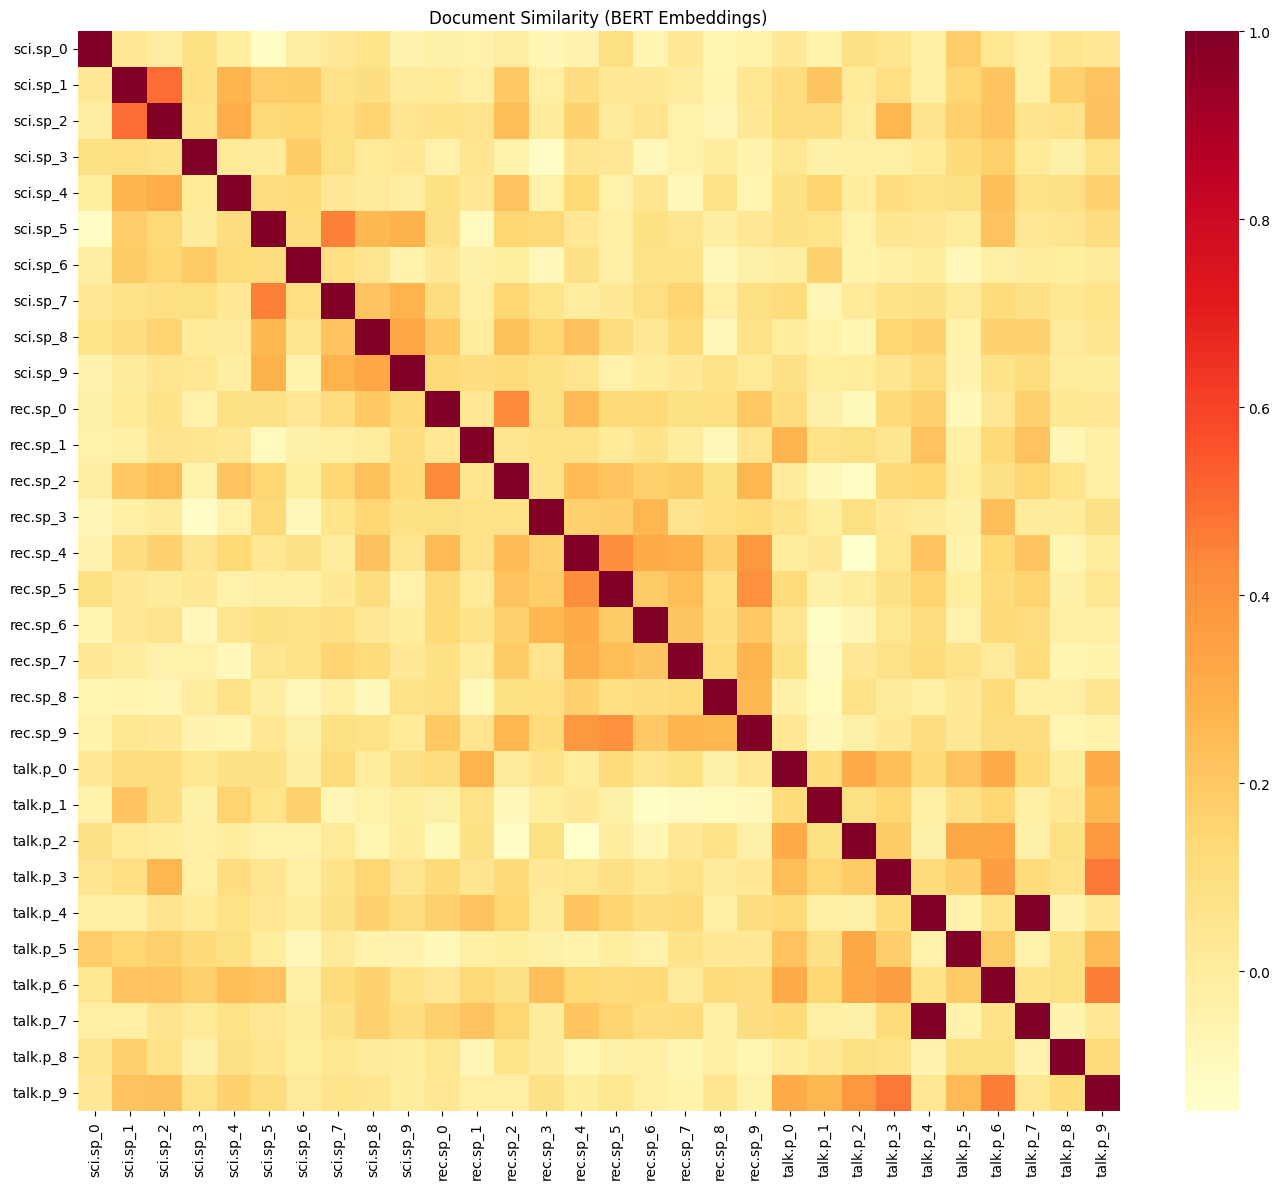

In [40]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with:  BERT. Looking at the heatmap, the three category blocks (sci.space, rec.sport.hockey, talk.politics.guns) are clearly visible along the diagonal — documents within the same category show much darker (higher similarity) squares compared to cross-category pairs which stay light yellow. TF-IDF would not produce such clean separation because it only looks at word overlap, not meaning.

2. Differences between methods:  Yes, there are interesting differences. For example, talk.p_3 shows slightly higher similarity with some sci.space documents   BERT picks up on a shared "policy/technical" tone even though the vocabulary is completely different (guns vs. space). TF-IDF would miss this because the words don't overlap. On the other hand, TF-IDF might incorrectly group a hockey document with a guns document just because both use the word "shot", while BERT correctly separates them by understanding the context.

3. Preferred method for classification: I would go with BERT. The heatmap clearly shows that within category similarities are consistently high while cross category ones stay low  that's exactly the kind of signal a classifier needs to work well. On top of that, BERT handles synonyms, paraphrases and ambiguous words naturally, which TF IDF simply can't do. The computational cost is higher, but for a real classification task, the quality improvement is absolutely worth it.

### Exercise C.2: Semantic Search with BERT

In [41]:
# Semantic search function using BERT embeddings
def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.

    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return

    Returns:
        list: List of (index, similarity_score) tuples
    """
    # Step 1: Encode the query
    query_embedding = model.encode([query])

    # Step 2: Encode all documents (or use pre-computed embeddings)
    doc_embs = model.encode(documents)

    # Step 3: Compute cosine similarity between query and all documents
    sims = cosine_similarity(query_embedding, doc_embs)[0]

    # Step 4: Get top_k indices sorted by similarity descending
    top_indices = sims.argsort()[::-1][:top_k]

    return [(int(idx), float(sims[idx])) for idx in top_indices]


# Test with a query related to sci.space
my_query = "NASA shuttle mission launch into orbit"

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'NASA shuttle mission launch into orbit'

Top 5 most similar documents:

  Score: 0.3149
  Category: sci.space
  Text: From another space forum
    When workers at the Kennedy Space Center disassembled the STS-56
 solid rocket boosters they were surprised to find a pai...

  Score: 0.1856
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.1690
  Category: sci.space
  Text: I am doing a political science paper on the funding of NASA and pork-barrel 
politics.  I would be interested in information about funding practices a...

  Score: 0.1256
  Category: sci.space
  Text: 

He's also the one who dubbed it the SR-71 - it was the RS-71 until LBJ
mippselled (sic) it.

FWIW,

Doug Page...

  Score: 0.1089
  Category: rec.sport.hockey
  Text: * The Keenan hiring is precipitated by the loss of an anticipated $5M
in playoff revenue and fears of 

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: The results are mostly relevant. The top 3 documents are all from sci.space and clearly relate to NASA, space funding, and shuttle programs  which matches the query well. However, the similarity scores are quite low overall (the best is only 0.31), which suggests BERT is finding the closest matches available in our small 30 document sample, but they are not a perfect semantic match to the query.

2. Category accuracy: Yes, mostly. 4 out of 5 results come from sci.space, which is exactly the expected category for a query about NASA shuttle launches. The model correctly identified that this query belongs to the space domain. The 5th result (rec.sport.hockey) is a bit surprising, but with such a low score (0.10) it's basically noise  it just happened to be slightly closer than other documents in the small sample.

3. Ambiguous query test: If we tried a query like "shooting practice" for example, the model would likely struggle because this phrase could relate to both rec.sport.hockey (players shooting on goal) and talk.politics.guns (gun practice). In that case, BERT might return mixed results from both categories, since it understands context but the query itself is genuinely ambiguous. This shows that semantic search works well for clear queries but can return mixed results when the intent is unclear.

---

## Part D: Embedding Visualization with t-SNE

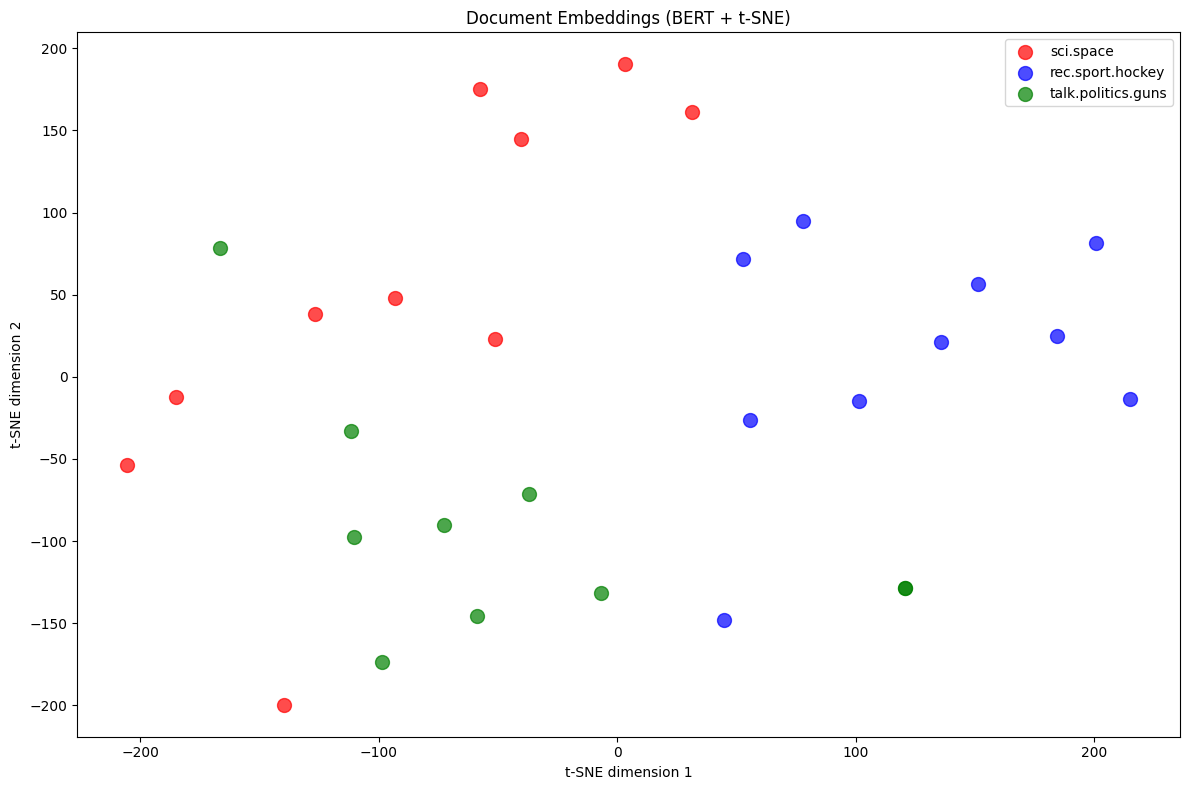

In [42]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = ['red', 'blue', 'green']

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    indices = [j for j, m in enumerate(mask) if m]
    plt.scatter(
        embeddings_2d[indices, 0],
        embeddings_2d[indices, 1],
        label=category,
        color=colors[i],
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality:The categories do not form very tight, distinct clusters. We can see a general tendency  blue dots (rec.sport.hockey) are mostly on the right side, red dots (sci.space) are more in the upper left/center area, and green dots (talk.politics.guns) are spread around the bottom-center. However, the separation is not clean at all, with points from different categories mixed together in several areas. This is partly due to the small sample size (only 10 documents per category)

2. Misplaced documents: Yes, there are a few. For example, one green dot (talk.politics.guns) appears isolated at the top-left near (-170, 78), far from the other green points. Similarly, one red dot (sci.space) sits at (-230, -55), quite far from the main red cluster. This could be because those documents discuss topics that happen to overlap with another category — for instance, a guns document that heavily discusses government policy might embed closer to space/science policy documents

3. Most similar categories: Looking at the plot, sci.space and talk.politics.guns seem to be the most similar — their points are the most interleaved, especially in the center-left region of the plot. This is a bit surprising at first, but it actually makes sense: both categories often discuss government funding, federal programs, and political debates, which gives them a shared "political/institutional" tone that BERT picks up on. This is consistent with what we observed in the BERT heatmap from C.1

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Very simple to understand and implement, no training needed, fully interpretable| Completely ignores word order and meaning; vectors are huge and sparse; common words pollute everything | Quick baseline, spam filtering, basic classification |
| TF-IDF | Much better than BoW — it "penalizes" overly frequent words and highlights what's truly specific to each category| Still no notion of meaning or context; two synonyms remain two completely different words| Information retrieval, document ranking, multi-class classification|
| Word2Vec | Actually starts capturing word meaning and relationships (analogies, synonyms); compact and useful vectors |One vector per word regardless of context; needs a large corpus to work well | Semantic similarity, clustering, recommendation|
| GloVe |Already pre-trained on millions of texts so very solid in general; stable and reproducible |  Like Word2Vec, remains static — it doesn't know that "right" changes meaning depending on the sentence| General NLP tasks, transfer learning |
| BERT | Truly contextual: the same word can have different representations depending on the sentence; state of the art on almost everything | Heavy, slow, hard to interpret, requires fine-tuning to be truly effective| Advanced classification, semantic search, NER, QA |

### 2. Best Method for My Dataset

For my three categories, BERT clearly gave the best results. What convinced me was mostly exercise C.1: documents from the same category were well grouped together, even when they didn't use the exact same words. The semantic search in C.2 was also telling — a query about "NASA rockets" would still retrieve relevant sci.space articles even without exact word matches.
That said, TF-IDF held up really well: the words it highlighted in E.1 (lunar, spacecraft, penalty, amendment) were far more representative than the BoW top words, which were polluted by generic terms like people or think. Word2Vec was a bit disappointing, but that's expected given how small the corpus was.
### 3. My Recommendation for a Real System

If I had to build a real classification system for these categories, my answer would depend on the project's constraints.
With limited resources → TF-IDF + SVM or logistic regression. The three categories have distinct enough vocabularies that it would work well, and it's fast, lightweight and easy to maintain in production.
If quality matters → fine-tune DistilBERT. What I saw in C.2 convinced me that BERT handles ambiguous cases well  for example "right" meaning a legal right in politics.guns but a direction in sci.space. In a real system, users never phrase their queries exactly like the training texts, and that's where BERT makes a real difference.
In short: TF-IDF for simplicity and efficiency, BERT when precision is what matters.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found